<a href="https://colab.research.google.com/github/Malvocado/Machine_Learing_Final_Project/blob/main/DataProcessingPipeLine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

Loading data from excel file to df using pandas

In [100]:
df = pd.read_excel('BMW sales data (2010-2024) (1).xlsx')

#Identify data type

In [101]:
# Check data types
print("Data Types:")
print(df.dtypes)

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Data Types:
Model                    object
Year                      int64
Region                   object
Color                    object
Fuel_Type                object
Transmission             object
Engine_Size_L           float64
Mileage_KM                int64
Price_USD                 int64
Sales_Volume              int64
Sales_Classification     object
dtype: object

Numerical columns: ['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume']
Categorical columns: ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification']


#Exploratory Data Analysis (EDA)

In [102]:
# Statistical summary for numerical features
print("Statistical Summary:")
df[numerical_cols].describe()

Statistical Summary:


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [103]:
# Value counts for categorical features
for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


Model value counts:
Model
7 Series    4666
i3          4618
i8          4606
3 Series    4595
5 Series    4592
X1          4570
X3          4497
X5          4487
M5          4478
X6          4478
M3          4413
Name: count, dtype: int64
Unique values: 11

Region value counts:
Region
Asia             8454
Middle East      8373
North America    8335
Europe           8334
Africa           8253
South America    8251
Name: count, dtype: int64
Unique values: 6

Color value counts:
Color
Red       8463
Silver    8350
Grey      8348
White     8304
Black     8273
Blue      8262
Name: count, dtype: int64
Unique values: 6

Fuel_Type value counts:
Fuel_Type
Hybrid      12716
Petrol      12550
Electric    12471
Diesel      12263
Name: count, dtype: int64
Unique values: 4

Transmission value counts:
Transmission
Manual       25154
Automatic    24846
Name: count, dtype: int64
Unique values: 2

Sales_Classification value counts:
Sales_Classification
Low     34754
High    15246
Name: count, dtype: i

##Visualize numerical data

We only visualize the X feature so Price column is excluded.

Visualizing distributions of original numerical features:


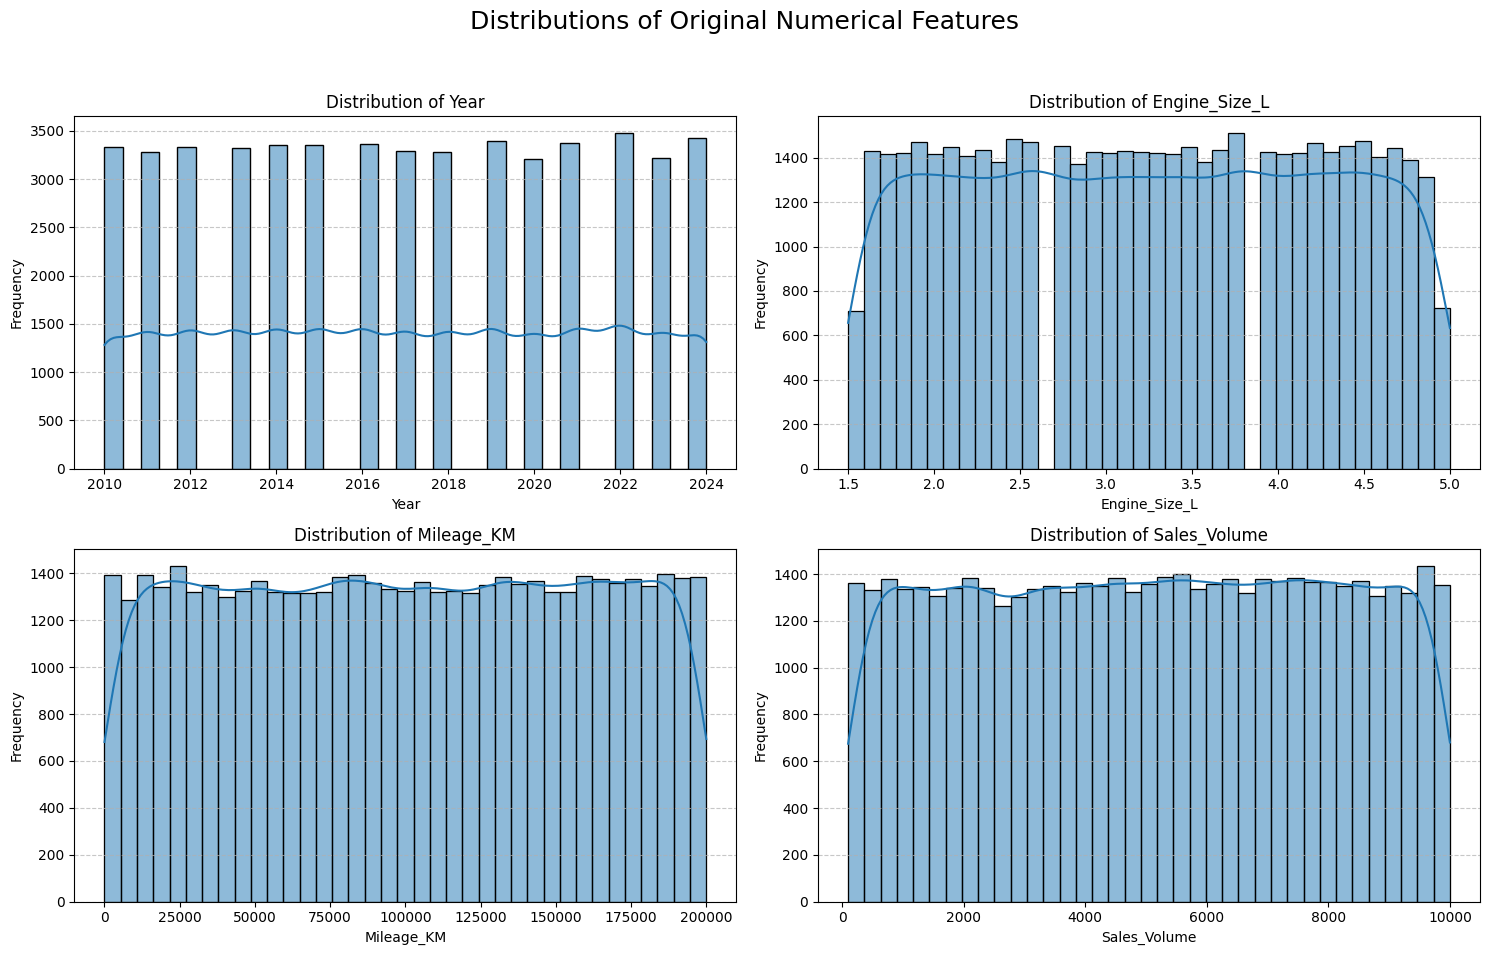

In [104]:
print("Visualizing distributions of original numerical features:")

plot_numerical_cols = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Sales_Volume']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

fig.suptitle('Distributions of Original Numerical Features', fontsize=18)

for i, col in enumerate(plot_numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

This is a box plot that we created for viewing the outlier

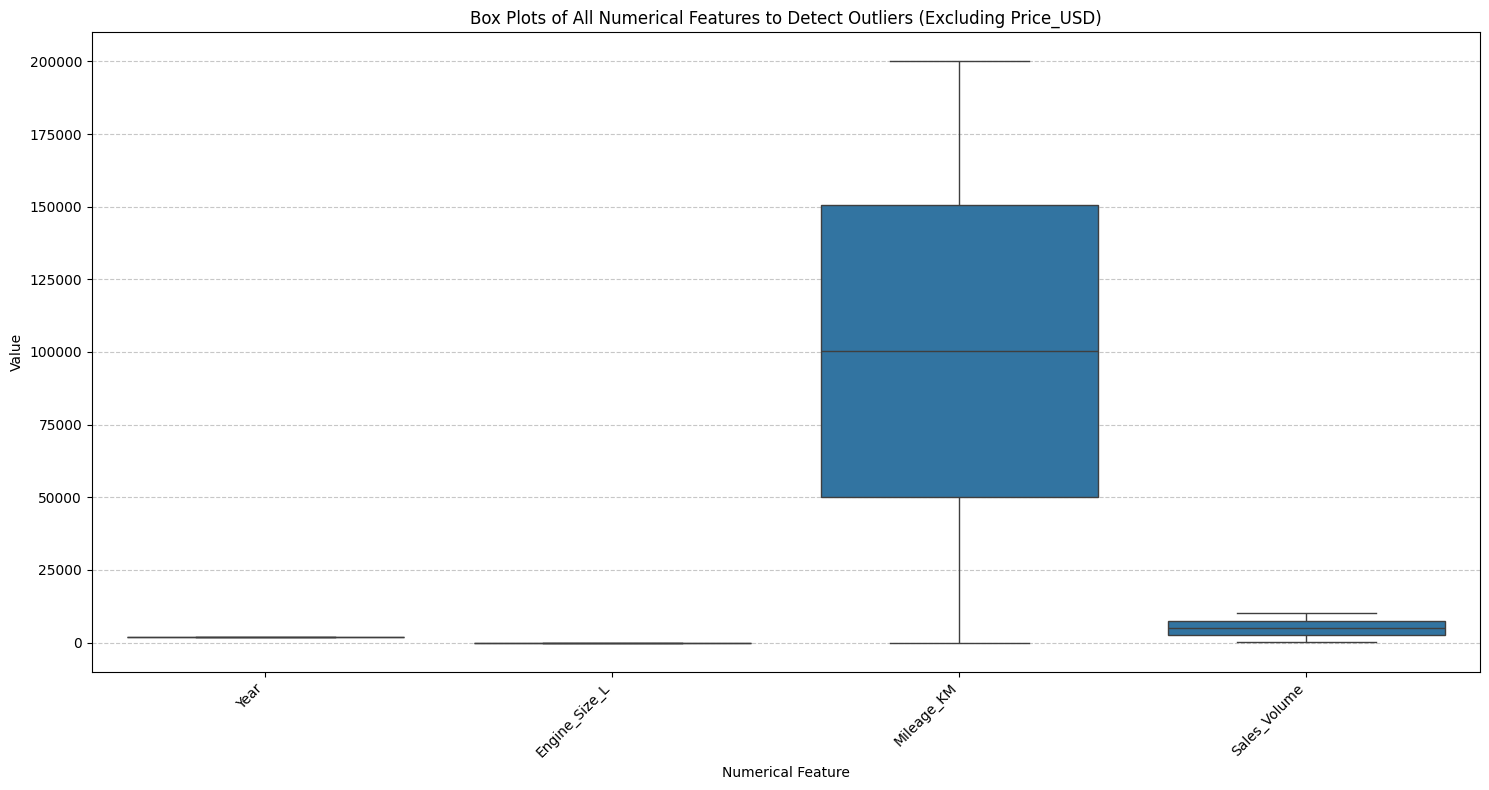

In [105]:
plot_numerical_cols_for_box_plot = [col for col in numerical_cols if col != 'Price_USD']
df_melted = df[plot_numerical_cols_for_box_plot].melt(var_name='Numerical_Feature', value_name='Value')

plt.figure(figsize=(15, 8))
sns.boxplot(x='Numerical_Feature', y='Value', data=df_melted)
plt.title('Box Plots of All Numerical Features to Detect Outliers (Excluding Price_USD)')
plt.xlabel('Numerical Feature')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Detecting Missing values

In [106]:
# Check for missing values
print("Missing Values Count:")
print(df.isnull().sum())

Missing Values Count:
Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Volume            0
Sales_Classification    0
dtype: int64


There is no missing value in the datast

#Detect and handle Outlier

In [107]:
# Detect outliers using the Z-score method
outlier_counts_zscore = {}
for col in numerical_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers_zscore = df[z_scores > 3]
    outlier_counts_zscore[col] = outliers_zscore.shape[0]

print("Outlier Counts (Z-score Method, |Z| > 3):")
for col, count in outlier_counts_zscore.items():
    print(f"  {col}: {count} outliers")

Outlier Counts (Z-score Method, |Z| > 3):
  Year: 0 outliers
  Engine_Size_L: 0 outliers
  Mileage_KM: 0 outliers
  Price_USD: 0 outliers
  Sales_Volume: 0 outliers


Since there is no outlier detected, we don't have to handle anything.

#Feature Scaling
Next step we are going to apply feature scaling on all numerical features by applying standard scaler. StandardScaler transform all data to have a mean of 0 and standard deviation of 1.

We only apply StandardScaler on X features not all numerical feature. So, Price feature is still the same.

In [108]:
# Define the numerical columns to scale
columns_to_scale = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Sales_Volume']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the selected columns
df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

print("DataFrame after applying StandardScaler:")
display(df.head())

DataFrame after applying StandardScaler:


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,-0.234876,Asia,Red,Petrol,Manual,0.250548,0.887814,98740,1.131530,High
1,i8,-0.928611,North America,Red,Hybrid,Automatic,-1.632377,0.368717,79219,-0.573911,Low
2,5 Series,1.152595,North America,Blue,Petrol,Automatic,1.241561,-1.541504,113265,0.674365,Low
3,X3,1.615085,Middle East,Blue,Petrol,Automatic,-1.533276,-1.260805,60971,-0.357231,Low
4,7 Series,0.690105,South America,Black,Diesel,Manual,-1.136871,0.376656,49898,-0.695729,Low


### Visualizing Features After Scaling

Visualizing distributions after scaling (2x2 grid):


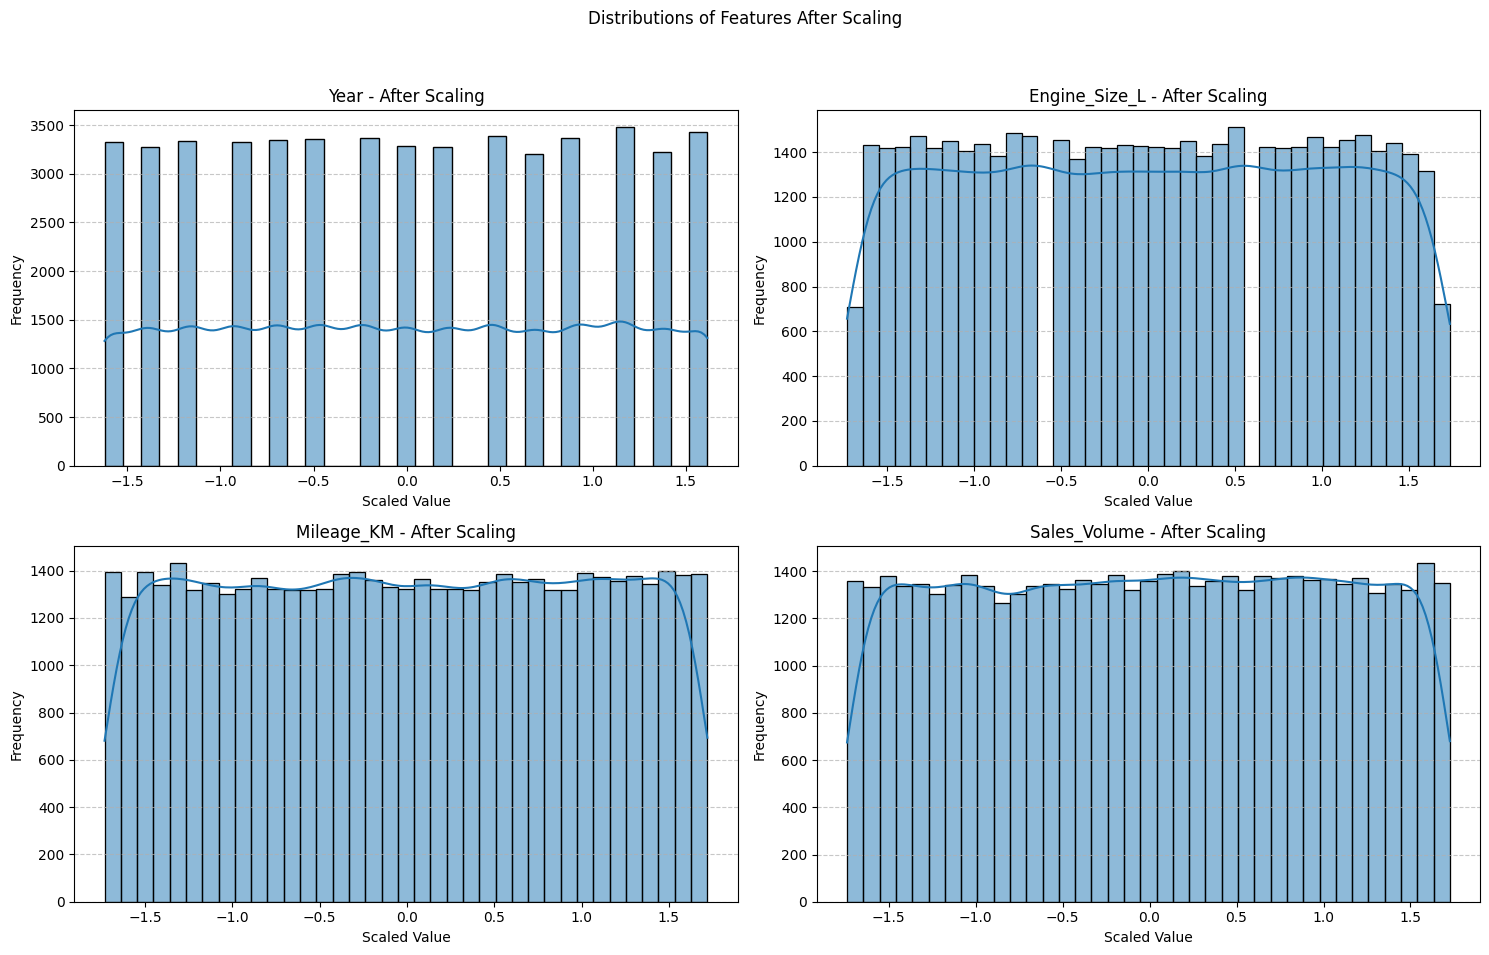

In [109]:
columns_to_scale = ['Year', 'Engine_Size_L', 'Mileage_KM', 'Sales_Volume']

print("Visualizing distributions after scaling (2x2 grid):")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

fig.suptitle('Distributions of Features After Scaling')

for i, col in enumerate(columns_to_scale):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} - After Scaling')
    axes[i].set_xlabel('Scaled Value')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Feature Encoding
For categorical feature ['Model', 'Region', 'Color', 'Fuel_Type', 'Transmission', 'Sales_Classification'] we will apply One-hot encoding to all column except 'Sales_Classification'. We will apply Label encoding to that feaature because this feature is ordinary data (Low, High).

Now that the `df` is in the correct pre-encoding state, we can apply feature encoding.

In [110]:
columns_for_onehot = [col for col in categorical_cols if col != 'Sales_Classification']

df = pd.get_dummies(df, columns=columns_for_onehot, drop_first=True)

label_encoder = LabelEncoder()
df['Sales_Classification'] = label_encoder.fit_transform(df['Sales_Classification'])

print("DataFrame after Feature Encoding:")
display(df.head())

DataFrame after Feature Encoding:


,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification,Model_5 Series,Model_7 Series,Model_M3,Model_M5,...,Region_South America,Color_Blue,Color_Grey,Color_Red,Color_Silver,Color_White,Fuel_Type_Electric,Fuel_Type_Hybrid,Fuel_Type_Petrol,Transmission_Manual
0,-0.234876,0.250548,0.887814,98740,1.131530,0,True,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,-0.928611,-1.632377,0.368717,79219,-0.573911,1,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
2,1.152595,1.241561,-1.541504,113265,0.674365,1,True,False,False,False,...,False,True,False,False,False,False,False,False,True,False
3,1.615085,-1.533276,-1.260805,60971,-0.357231,1,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
4,0.690105,-1.136871,0.376656,49898,-0.695729,1,False,True,False,False,...,True,False,False,False,False,False,False,False,False,True


In [111]:
print("All encoded features (columns) in the DataFrame:")
print(df.columns.tolist())

All encoded features (columns) in the DataFrame:
['Year', 'Engine_Size_L', 'Mileage_KM', 'Price_USD', 'Sales_Volume', 'Sales_Classification', 'Model_5 Series', 'Model_7 Series', 'Model_M3', 'Model_M5', 'Model_X1', 'Model_X3', 'Model_X5', 'Model_X6', 'Model_i3', 'Model_i8', 'Region_Asia', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Region_South America', 'Color_Blue', 'Color_Grey', 'Color_Red', 'Color_Silver', 'Color_White', 'Fuel_Type_Electric', 'Fuel_Type_Hybrid', 'Fuel_Type_Petrol', 'Transmission_Manual']


In [112]:
# Export the processed DataFrame to a CSV file
df.to_csv('BMW_sales_data_after_processing.csv', index=False)

print("Feature-processed data exported successfully to 'processed_bmw_sales_data.csv'")

Feature-processed data exported successfully to 'processed_bmw_sales_data.csv'
